In [105]:
import pandas as pd

## Prepare data file

In [130]:
df = pd.read_csv("/Users/xiaoenda/WORK/2_ML_Heusler/4_MLFF_opt/data/DXMag_heusler_ground.csv", index_col=0).sample(100)

In [131]:
df = df.sort_index()
df.shape

(100, 76)

In [132]:
# df.columns

In [133]:
for ind,row in df.iterrows():
    df.loc[ind, 'numbers'] = row['numbers'].replace(' ', ', ')
    # print(row['numbers'])
    # print(row['cell'])
    # break

In [134]:
df.shape

(100, 76)

In [135]:
cols = ['composition', 'type', 'cell', 'positions', 'numbers']
df[cols].to_csv('./example_data.csv')

cols = ['composition', 'type', 'cell', 'positions', 'numbers', 'energy (eV/atom)', 'formation energy (eV/atom)', 'hull distance (eV/atom)']
df[cols].to_csv('./example_data_dft.csv')

In [136]:
df[cols].shape

(100, 8)

## Validate result

In [113]:

import argparse
import ast
import os
from math import sqrt
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import spglib
from mpi4py import MPI

# ASE imports
from ase import Atoms
from ase.constraints import FixSymmetry
from ase.filters import FrechetCellFilter
from ase.optimize import FIRE
from ase.calculators.calculator import Calculator

# PyMatGen imports
from pymatgen.core import Lattice, Structure
from pymatgen.core.operations import SymmOp
from pymatgen.io.ase import AseAtomsAdaptor

import warnings
warnings.filterwarnings('ignore')

# Suppress specific warnings from common libraries
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Suppress PyMatGen warnings
warnings.filterwarnings('ignore', module='pymatgen')

# Suppress ASE warnings
warnings.filterwarnings('ignore', module='ase')

# Suppress NumPy warnings
np.seterr(all='ignore')

# Constants
DEFAULT_TOLERANCE = 1e-10
DEFAULT_SYMPREC = 0.01
DEFAULT_FMAX = 0.0001
DEFAULT_MAX_STEPS = 200

import matplotlib.pyplot as plt

In [114]:

def str_to_2d_array(string: str) -> Optional[np.ndarray]:
    """
    Convert a string representation of a 2D array to a NumPy array.
    
    Args:
        string: String representation of a 2D array
        
    Returns:
        NumPy array if conversion is successful, None otherwise
    """
    if ',' not in string:
        string = string.replace(' ', ',')
    try:
        list_of_lists = ast.literal_eval(string)
        return np.array(list_of_lists)
    except (ValueError, SyntaxError):
        return None


def clean_matrix(matrix: np.ndarray, decimals: int = 6) -> np.ndarray:
    """
    Clean matrix by rounding to specified decimal places.
    
    Args:
        matrix: Input matrix to clean
        decimals: Number of decimal places to round to
        
    Returns:
        Cleaned matrix
    """
    return np.round(matrix, decimals=decimals)
    
def symmetrize_structure(structure: Structure, symprec: float = DEFAULT_SYMPREC) -> Tuple[Structure, Optional[str]]:
    """
    Convert non-primitive to primitive structure.
    The primitive from this function is 'standard' in our database.
    
    Args:
        structure: Input pymatgen Structure
        symprec: Symmetry precision tolerance
        
    Returns:
        Tuple of (primitive structure, spacegroup symbol)
    """
    cell = (structure.lattice.matrix, structure.frac_coords, structure.atomic_numbers)
    try:
        lattice, scaled_positions, numbers = spglib.standardize_cell(
            cell, 
            to_primitive=True, 
            no_idealize=False, 
            symprec=symprec
        )
        spacegroup_symbol = spglib.get_spacegroup(cell, symprec=symprec)
        return Structure(Lattice(lattice), numbers, scaled_positions), spacegroup_symbol
    except Exception as e:
        print(f"Warning: Could not symmetrize structure: {e}")
        return structure, None

def get_structure(system: pd.Series, cell_col: str = 'cell', positions_col: str = 'positions', numbers_col: str = 'numbers', symmetrize: bool = False) -> Tuple[Structure, str]:
    """
    Convert pandas Series data to pymatgen Structure object.
    
    Args:
        system: pandas Series containing structure data
        cell_col: Column name for cell data (default: 'cell')
        positions_col: Column name for positions data (default: 'positions')  
        numbers_col: Column name for numbers data (default: 'numbers')
        symmetrize: Whether to symmetrize the structure to primitive cell (default: False)
        
    Returns:
        Tuple of (Structure object, spacegroup symbol)
    """
    cell = str_to_2d_array(system[cell_col])
    positions = str_to_2d_array(system[positions_col])
    
    try:
        numbers = str_to_2d_array(system[numbers_col])
    except (KeyError, ValueError):
        numbers = str_to_2d_array(system[numbers_col].replace(' ', ','))
    
    if cell is None or positions is None or numbers is None:
        raise ValueError("Could not parse structure data from system")
    
    lattice = Lattice(cell)
    structure = Structure(lattice, numbers, positions)
    
    if symmetrize:
        structure, spacegroup_symbol = symmetrize_structure(structure)
        if spacegroup_symbol is None:
            return structure, "Unknown"
        return structure, spacegroup_symbol.split()[0]
    else:
        # Get spacegroup without symmetrizing
        cell_data = (structure.lattice.matrix, structure.frac_coords, structure.atomic_numbers)
        try:
            spacegroup_symbol = spglib.get_spacegroup(cell_data, symprec=DEFAULT_SYMPREC)
            return structure, spacegroup_symbol.split()[0] if spacegroup_symbol else "Unknown"
        except Exception:
            return structure, "Unknown"

In [118]:
df = pd.read_csv('./example_data_result.csv', index_col=0)

In [119]:
dft = []
ml  = []
for ind, row in df.iterrows():
    struc = get_structure(row, symmetrize=False)[0]
    dft.append(struc.lattice.matrix[0,1])

    struc = get_structure(row, 
                          cell_col='optimized_cell', 
                          positions_col='optimized_positions', 
                          numbers_col='optimized_numbers', 
                          symmetrize=False
                         )[0]
    ml.append(struc.lattice.matrix[0,1])

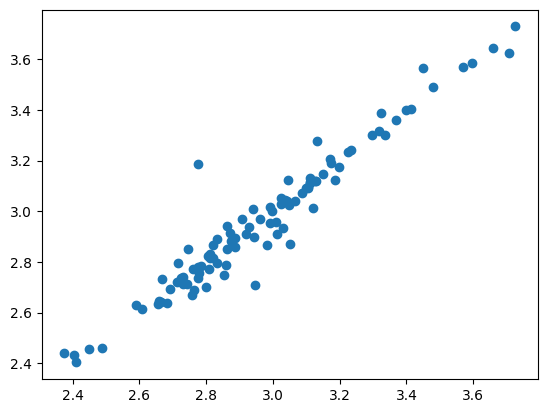

In [120]:
plt.plot(dft, ml, 'o')

In [89]:
df[['cell', 'optimized_cell']]

,cell,optimized_cell
7366,"[[2.6537902, 2.6537902, 0.0], [-2.6537902, 2.6...","[[2.7287839328347645, 2.7287839328347645, -3.3..."
51538,"[[3.27190773, 3.27190773, -0.0], [-3.27190773,...","[[3.245022947167429, 3.245022947167428, -1.800..."
92842,"[[3.04025027, 3.04025027, 0.0], [-3.04025027, ...","[[3.0183021039525757, 3.018302103952585, -4.43..."
58969,"[[2.78508084, 2.78508084, 0.0], [-2.78508084, ...","[[2.7898710804594917, 2.7898710804594886, -1.9..."
97626,"[[2.83019753, 2.83019753, -0.0], [-2.83019753,...","[[2.932972361352526, 2.932972361352526, 2.0840..."
...,...,...
49767,"[[3.14861583, 3.14861583, -0.0], [-3.14861583,...","[[3.146012168669031, 3.1460121686690297, 1.881..."
22214,"[[3.11831548, 3.11831548, -0.0], [-3.11831548,...","[[3.131324221018316, 3.1313242210183097, 3.135..."
85349,"[[2.88836566, 2.88836566, -0.0], [-2.88836566,...","[[2.7893906214636757, 2.7893906214636757, 2.44..."
84322,"[[2.54287315, 2.54287315, 0.0], [-2.54287315, ...","[[2.539445724434592, 2.539445724434592, 5.8301..."


In [128]:
ml  = pd.read_csv('./example_data_result_formation_energy.csv', index_col=0)['Formation Energy (eV/atom)']
dft = pd.read_csv('./example_data_dft.csv', index_col=0)['formation energy (eV/atom)']

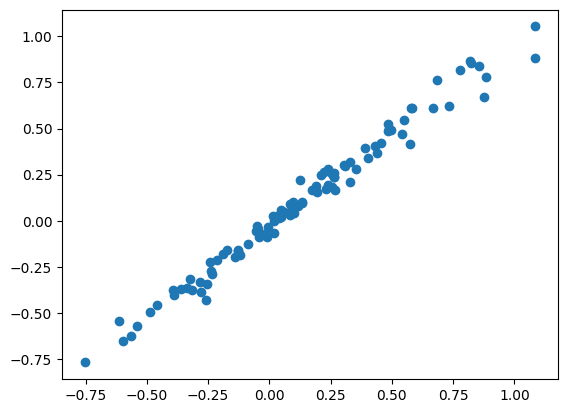

In [129]:
plt.plot(dft, ml, 'o')